# Analyze Intrinsic Metrics

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../../scripts/")
from analysis.model_info import MODEL_INFORMATION
%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_json(
    "data/compiled_intrinsic_metrics_ar-cs-de.jsonl",
    orient="records",
    lines=True,
)

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler


def calculate_quality_score(df):
    """Calculate an aggregate quality score from intrinsic metrics using z-score normalization.

    Each metric is standardized (mean=0, std=1) and then averaged. This approach:
    - Handles extreme outliers automatically
    - Gives equal weight to each metric in terms of variance
    - Incorporates all 4 metrics: prompts_distinct_ri, responses_distinct_ri,
      rubric_score, and perplexity (log-transformed and inverted)

    df (pd.DataFrame): DataFrame with columns: prompts_distinct_ri,
        responses_distinct_ri, rubric_score, perplexity

    RETURNS (pd.Series): Quality scores for each row (higher is better)
    """
    data = np.column_stack(
        [
            df["prompts_distinct_ri"],
            df["responses_distinct_ri"],
            df["rubric_score"],
            -np.log1p(df["perplexity"]),
        ]
    )

    # Standardize and average
    scaler = StandardScaler()
    normalized = scaler.fit_transform(data)
    quality_score = normalized.mean(axis=1)

    return quality_score

In [4]:
# Calculate quality score
df["quality_score"] = calculate_quality_score(df)

# Show top models by quality score
df[
    [
        "language",
        "model",
        "quality_score",
        "rubric_score",
        "responses_distinct_ri",
        "prompts_distinct_ri",
        "perplexity",
    ]
].sort_values("quality_score", ascending=False)

,language,model,quality_score,rubric_score,responses_distinct_ri,prompts_distinct_ri,perplexity
22,de,google/gemma-3-12b-it,0.978179,4.2028,0.898606,0.751085,4.060759
24,de,google/gemma-3-4b-it,0.882591,4.1030,0.897925,0.744396,3.963183
23,de,google/gemma-3-27b-it,0.827283,4.2601,0.897766,0.730997,3.960716
21,de,cohere-command-a,0.738747,4.2353,0.889303,0.729790,3.586949
25,de,gpt-4o-mini-2024-07-18,0.597294,3.8100,0.888769,0.731964,3.650469
20,de,CohereLabs/aya-expanse-32b,0.574391,4.1400,0.901674,0.700103,3.441957
27,de,ibm-granite/granite-4.0-micro,0.523330,3.7037,0.892299,0.725769,4.591788
3,ar,google/gemma-3-27b-it,0.515359,3.9315,0.889779,0.717244,4.403990
0,ar,CohereLabs/aya-expanse-32b,0.310859,3.9640,0.888060,0.692789,4.337098
13,cs,google/gemma-3-27b-it,0.283105,4.3416,0.884775,0.675320,3.772706


In [5]:
from analysis import plot_theme

plot_params = plot_theme.PLOT_PARAMS.copy()
plt.rcParams.update(plot_params)

Figure saved to figures/model_size_vs_quality_by_language.png


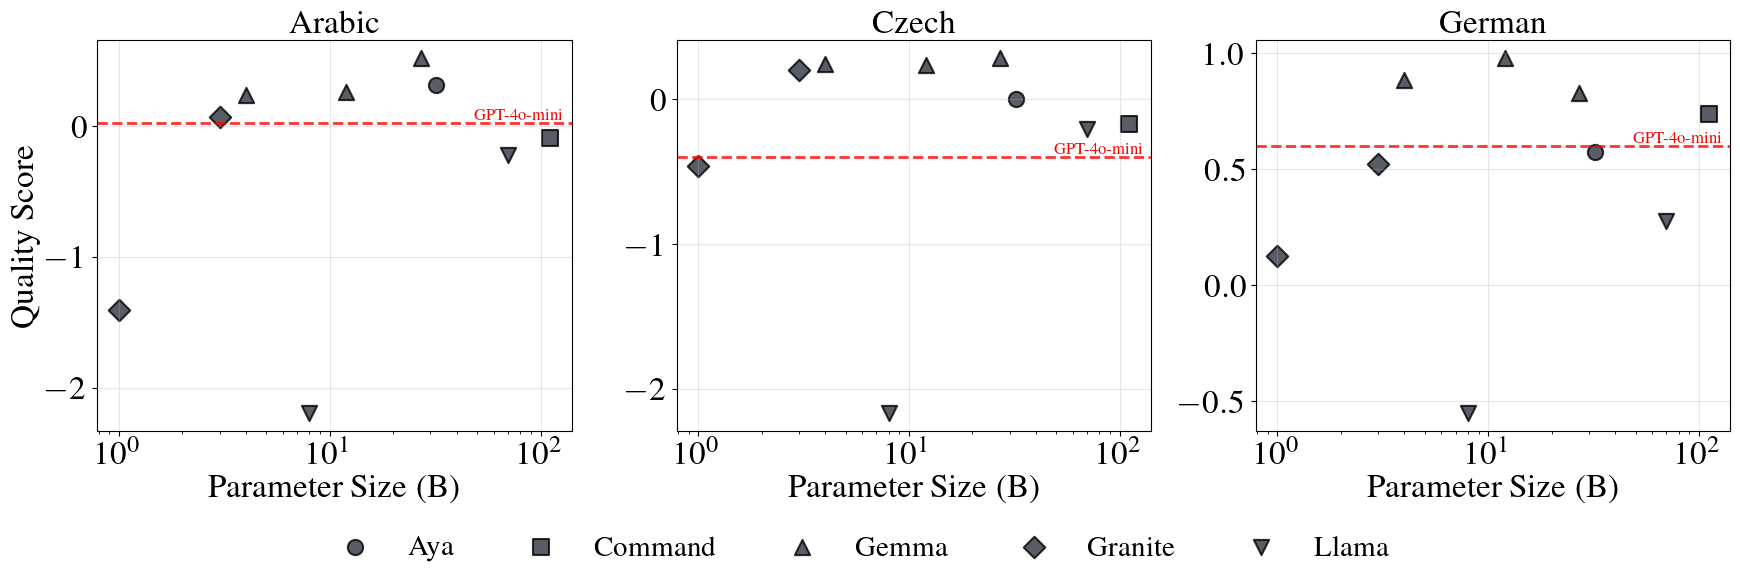

In [42]:
# Merge model size information
model_info_df = pd.DataFrame([m.model_dump() for m in MODEL_INFORMATION])
df_with_size = df.merge(
    model_info_df[["name", "parameter_size", "model_family"]],
    left_on="model",
    right_on="name",
    how="left",
)

# Create 1x3 subplot for each language
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

languages = ["ar", "cs", "de"]
language_names = {"ar": "Arabic", "cs": "Czech", "de": "German"}

# Define markers for different model families
family_markers = {
    "Aya": "o",
    "Command": "s",
    "Gemma": "^",
    "Granite": "D",
    "Llama": "v",
}

for idx, (lang, ax) in enumerate(zip(languages, axes)):
    # Filter data for this language
    df_lang = df_with_size[df_with_size["language"] == lang]
    df_lang_plot = df_lang[df_lang["parameter_size"] != "Unknown"].copy()
    df_lang_plot["parameter_size"] = df_lang_plot["parameter_size"].astype(float)

    # Get GPT-4o-mini quality score for this language
    gpt4o_mini_lang = df_lang[df_lang["model"] == "gpt-4o-mini-2024-07-18"]
    gpt4o_mini_quality_lang = gpt4o_mini_lang["quality_score"].iloc[0]

    # Plot each model family with different markers
    families = df_lang_plot["model_family"].unique()
    for family in families:
        family_data = df_lang_plot[df_lang_plot["model_family"] == family]
        ax.scatter(
            family_data["parameter_size"],
            family_data["quality_score"],
            label=family if idx == 2 else "",  # Only show legend on last plot
            color="#2E3440",  # Dark gray/blue color
            marker=family_markers.get(family, "o"),
            s=120,
            alpha=0.8,
            edgecolors="black",
            linewidth=1.5,
        )

    # Add horizontal line for GPT-4o-mini
    ax.axhline(
        y=gpt4o_mini_quality_lang,
        color="red",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
    )

    # Add text label near the line
    ax.text(
        0.98,
        gpt4o_mini_quality_lang,
        "GPT-4o-mini",
        transform=ax.get_yaxis_transform(),
        fontsize=12,
        color="red",
        va="bottom",
        ha="right",
    )

    ax.set_title(language_names[lang])
    ax.set_xlabel("Parameter Size (B)")
    ax.set_xscale("log")
    ax.set_ylabel("Quality Score" if idx == 0 else "")
    ax.grid(True, alpha=0.3)

# Add legend centered below all subplots
fig.legend(
    *axes[2].get_legend_handles_labels(),
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=5,
    fontsize=21,
)

plt.tight_layout()

# Save figure
import os

os.makedirs("figures", exist_ok=True)
fig.savefig(
    "figures/model_size_vs_quality_by_language.png", dpi=300, bbox_inches="tight"
)
print("Figure saved to figures/model_size_vs_quality_by_language.png")

plt.show()